Practice 5

5. Using the imbalanced data from notebook 2 section 8.2, train a real LogisticRegression (not DummyClassifier). Generate matching features, for example X_imbalanced = np.random.default_rng(42).normal(size=(1000, 2)) related to y_imbalanced. Does it beat the "always healthy" baseline on recall? By how much? Plot both models' confusion matrices side by side.

In [41]:
# Import the libraries needed to create the data, train the models, calculate recall, and display confusion matrices.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

Cell 2

In [42]:
# Create an imbalanced dataset with 950 healthy samples and 50 disease samples.

y_imbalanced = np.array([0] * 950 + [1] * 50)

print("Healthy:", (y_imbalanced == 0).sum())
print("Disease:", (y_imbalanced == 1).sum())

Healthy: 950
Disease: 50


Cell 3

In [43]:
# Generate two features that are related to the target labels.

rng = np.random.default_rng(42)

X_imbalanced = rng.normal(loc=y_imbalanced.reshape(-1, 1),scale=1.0,size=(1000, 2))

print("X shape:", X_imbalanced.shape)

X shape: (1000, 2)


Cell 4

In [44]:
# Check that the features and labels have matching sample counts.

print("Features:", X_imbalanced.shape)
print("Labels:", y_imbalanced.shape)

Features: (1000, 2)
Labels: (1000,)


Cell 5

In [45]:
# The baseline always predicts the majority class, healthy.

dummy = DummyClassifier(strategy="constant",constant=0)

dummy.fit(X_imbalanced,y_imbalanced)

y_dummy_pred = dummy.predict(X_imbalanced)

Cell 6

In [46]:
# Train a real Logistic Regression model on the imbalanced dataset.

logreg_imbalanced = LogisticRegression(max_iter=5000)

logreg_imbalanced.fit(X_imbalanced,y_imbalanced)

y_logreg_pred = logreg_imbalanced.predict(X_imbalanced)

Cell 7

In [47]:
# Recall measures how many actual disease cases the model correctly detects.

dummy_recall = recall_score(y_imbalanced,y_dummy_pred,pos_label=1)

logreg_recall = recall_score(y_imbalanced,y_logreg_pred, pos_label=1)

print("Dummy recall:", round(dummy_recall, 4))
print("Logistic Regression recall:", round(logreg_recall, 4))

Dummy recall: 0.0
Logistic Regression recall: 0.0


Cell 8

In [48]:
# Recall improvement is the Logistic Regression recall minus the baseline recall.

recall_improvement = logreg_recall - dummy_recall

print("Recall improvement:",round(recall_improvement, 4))

Recall improvement: 0.0


Cell 9 

In [49]:
# Compare the disease recall of the baseline and Logistic Regression.

print("-" * 19)
print("Recall comparison")
print("-" * 19)

print("Always healthy:",round(dummy_recall, 4))

print("Logistic Regression:",round(logreg_recall, 4))

print("Improvement:",round(recall_improvement, 4))

-------------------
Recall comparison
-------------------
Always healthy: 0.0
Logistic Regression: 0.0
Improvement: 0.0


Cell 10 

In [50]:
# Calculate the confusion matrix for the always-healthy baseline.

cm_logreg = confusion_matrix(y_imbalanced,y_logreg_pred)

print(cm_logreg)

[[949   1]
 [ 50   0]]


Cell 11 

In [51]:
# Calculate the confusion matrix for Logistic Regression.

cm_logreg = confusion_matrix(y_imbalanced,y_logreg_pred)

print(cm_logreg)

[[949   1]
 [ 50   0]]


Cell 12

In [52]:
# A confusion matrix compares predictions with true labels.

cm_dummy = confusion_matrix(y_imbalanced,y_dummy_pred)

cm_logreg = confusion_matrix(y_imbalanced,y_logreg_pred)

Cell 13

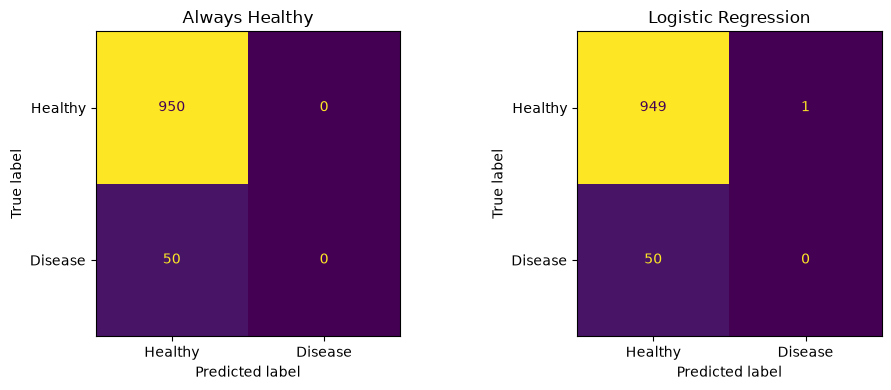

In [53]:
# Plot the two confusion matrices side by side to compare the models.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_dummy,display_labels=["Healthy", "Disease"]
).plot(ax=axes[0],colorbar=False)

axes[0].set_title("Always Healthy")

ConfusionMatrixDisplay(cm_logreg,display_labels=["Healthy", "Disease"]
).plot(ax=axes[1],colorbar=False)

axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

Cell 14

In [54]:
# Determine whether Logistic Regression beats the always-healthy baseline on disease recall.

print("-" * 11)
print("Exercise 5")
print("-" * 11)

print("Baseline recall:",round(dummy_recall, 4))

print("Logistic Regression recall:",round(logreg_recall, 4))

print("Recall improvement:",round(recall_improvement, 4))

if logreg_recall > dummy_recall:
    print("Logistic Regression beats the baseline.")
else:
    print("Logistic Regression does not beat the baseline.")

-----------
Exercise 5
-----------
Baseline recall: 0.0
Logistic Regression recall: 0.0
Recall improvement: 0.0
Logistic Regression does not beat the baseline.
